# Toxic Comment Classification

**Objective:** Detect harmful comments for moderation queues while highlighting context, fairness, and appeal workflows.

This notebook uses deterministic demo text so the complete workflow runs without private or externally hosted data. Labels are used only for supervised training and evaluation.


## 1. Setup and reproducibility


In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="deep")

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__} | NumPy: {np.__version__} | scikit-learn: {sklearn.__version__}")
print(f"Random seed: {RANDOM_STATE}")


Python: 3.12.13
pandas: 2.2.3 | NumPy: 2.3.5 | scikit-learn: 1.8.0
Random seed: 42


## 2. Build the documented demo dataset


In [2]:
TOPICS = {
  "constructive": [
    "helpful",
    "consider",
    "evidence",
    "suggestion",
    "respect",
    "clarify",
    "improve",
    "discussion"
  ],
  "toxic": [
    "idiot",
    "hate",
    "worthless",
    "stupid",
    "attack",
    "awful",
    "trash",
    "shut-up"
  ]
}
COMMON_WORDS = ["customer", "service", "today", "online", "request", "information", "please", "system"]
rows = []
for label, vocabulary in TOPICS.items():
    for row_id in range(180):
        signal = rng.choice(vocabulary, size=6, replace=True).tolist()
        context = rng.choice(COMMON_WORDS, size=4, replace=True).tolist()
        other_labels = [name for name in TOPICS if name != label]
        cross_noise = []
        if rng.random() < 0.35:
            other = rng.choice(other_labels)
            cross_noise = rng.choice(TOPICS[other], size=3, replace=True).tolist()
        tokens = signal + context + cross_noise
        rng.shuffle(tokens)
        observed_label = rng.choice(other_labels) if rng.random() < 0.08 else label
        rows.append({"comment_text": " ".join(tokens), "moderation_label": observed_label})

data = pd.DataFrame(rows).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print(f"Dataset shape: {data.shape[0]:,} rows × {data.shape[1]} columns")
display(data.head())
display(data["moderation_label"].value_counts().rename("count").to_frame())


Dataset shape: 360 rows × 2 columns


,comment_text,moderation_label
0,awful respect awful attack request customer ev...,toxic
1,clarify request request evidence consider sugg...,constructive
2,customer information idiot idiot trash custome...,toxic
3,stupid attack today awful stupid stupid custom...,constructive
4,consider discussion suggestion please system r...,constructive


,count
moderation_label,
constructive,182
toxic,178


## 3. Data quality and exploratory analysis


,dtype,missing,unique
comment_text,object,0,360
moderation_label,object,0,2


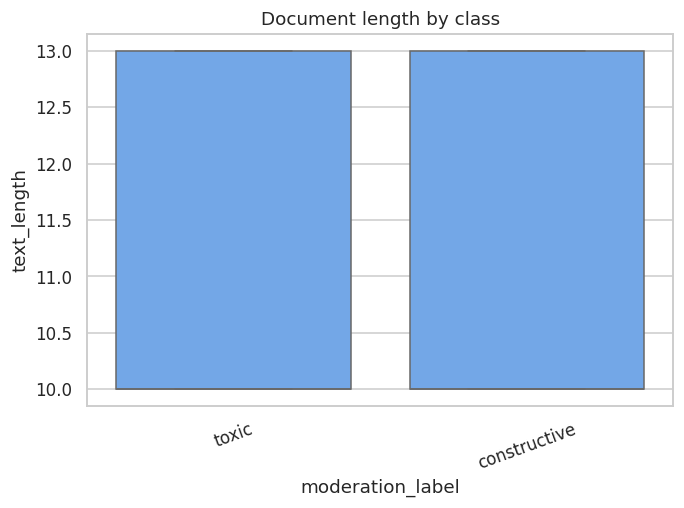

In [3]:
quality = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "unique": data.nunique(),
})
display(quality)
data["text_length"] = data["comment_text"].str.split().str.len()
sns.boxplot(data=data, x="moderation_label", y="text_length", color="#60a5fa")
plt.title("Document length by class")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 4. Leakage-safe split, baseline, and candidate models


In [4]:
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

X_train, X_test, y_train, y_test = train_test_split(
    data["comment_text"], data["moderation_label"], test_size=0.25,
    random_state=RANDOM_STATE, stratify=data["moderation_label"],
)
models = {
    "Majority baseline": Pipeline([("tfidf", TfidfVectorizer()), ("model", DummyClassifier(strategy="prior"))]),
    "Multinomial Naive Bayes": Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2)), ("model", MultinomialNB(alpha=0.6))]),
    "Logistic Regression": Pipeline([("tfidf", TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True)), ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
comparison = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring="f1_macro", n_jobs=1)
    comparison.append({"model": name, "cv_macro_f1": scores["test_score"].mean(), "cv_std": scores["test_score"].std()})
comparison = pd.DataFrame(comparison).sort_values("cv_macro_f1", ascending=False).reset_index(drop=True)
display(comparison.round(4))


,model,cv_macro_f1,cv_std
0,Multinomial Naive Bayes,0.9296,0.0246
1,Logistic Regression,0.9296,0.0246
2,Majority baseline,0.3350,0.0033


## 5. Holdout evaluation


Selected model: Multinomial Naive Bayes
Holdout accuracy: 0.8444
Holdout macro F1: 0.8444


,precision,recall,f1-score,support
constructive,0.8810,0.8043,0.8409,46.0000
toxic,0.8125,0.8864,0.8478,44.0000
accuracy,0.8444,0.8444,0.8444,0.8444
macro avg,0.8467,0.8454,0.8444,90.0000
weighted avg,0.8475,0.8444,0.8443,90.0000


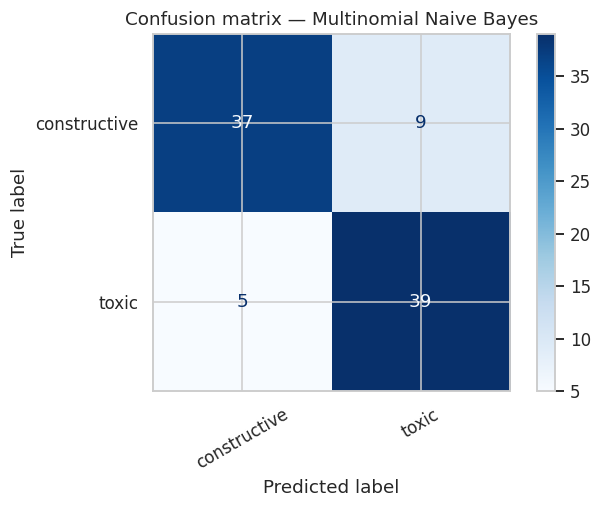

In [5]:
best_name = comparison.iloc[0]["model"]
best_model = models[best_name].fit(X_train, y_train)
predictions = best_model.predict(X_test)
print(f"Selected model: {best_name}")
print(f"Holdout accuracy: {accuracy_score(y_test, predictions):.4f}")
print(f"Holdout macro F1: {f1_score(y_test, predictions, average='macro'):.4f}")
display(pd.DataFrame(classification_report(y_test, predictions, output_dict=True, zero_division=0)).T.round(4))
ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap="Blues", xticks_rotation=30)
plt.title(f"Confusion matrix — {best_name}")
plt.tight_layout()
plt.show()


## 6. Model interpretation and sample predictions


In [6]:
if best_name == "Logistic Regression":
    vectorizer = best_model.named_steps["tfidf"]
    classifier = best_model.named_steps["model"]
    terms = np.asarray(vectorizer.get_feature_names_out())
    rows = []
    coefficients = classifier.coef_ if len(classifier.classes_) > 2 else np.vstack([-classifier.coef_[0], classifier.coef_[0]])
    for class_name, weights in zip(classifier.classes_, coefficients):
        for term, weight in zip(terms[np.argsort(weights)[-8:]], np.sort(weights)[-8:]):
            rows.append({"class": class_name, "term": term, "weight": weight})
    display(pd.DataFrame(rows).sort_values(["class", "weight"], ascending=[True, False]).round(3))

sample = pd.DataFrame({"text": X_test.iloc[:8], "actual": y_test.iloc[:8], "predicted": predictions[:8]})
display(sample)


,text,actual,predicted
36,evidence awful trash online service evidence c...,constructive,constructive
26,clarify discussion request please discussion h...,constructive,constructive
187,service customer idiot worthless awful trash w...,toxic,toxic
236,improve system discussion helpful suggestion s...,constructive,constructive
196,clarify consider suggestion idiot improve disc...,toxic,constructive
195,helpful information information respect system...,constructive,constructive
255,consider online please hate suggestion system ...,toxic,toxic
231,hate trash awful worthless request today servi...,toxic,toxic


## 7. Responsible-use notes and next steps

- Replace deterministic demo text with versioned, licensed, representative data.
- Review class definitions, annotation quality, subgroup performance, and threshold costs with domain experts.
- Keep humans in the loop for hiring, moderation, security, healthcare, finance, and other consequential decisions.
- Monitor vocabulary drift and abstain when confidence or data quality is low.
